In [188]:
import numpy as np 
import pandas as pd 
import statistics as sts 
import joblib 
import streamlit as st
import seaborn as sns 
import warnings
import traceback
import time 
from sklearn.preprocessing import StandardScaler,MinMaxScaler,RobustScaler,LabelEncoder,OrdinalEncoder,PowerTransformer
from sklearn.model_selection import cross_val_score, GridSearchCV,train_test_split
from sklearn.linear_model import LinearRegression,Lasso,Ridge,ElasticNet,LogisticRegression
from sklearn.ensemble import RandomForestClassifier,RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest,f_classif,f_regression
from sklearn.metrics import r2_score,f1_score,precision_score,recall_score,classification_report,confusion_matrix,mean_absolute_error,mean_squared_error,root_mean_squared_error
from sklearn.compose import ColumnTransformer
from matplotlib import pyplot as plt

In [189]:
warnings.filterwarnings('ignore')

In [190]:
df1=pd.read_csv(r"C:\Shravan\PythonPratice\supervised\machineLearning1\pred11\Coffe_sales.csv",encoding_errors='ignore')

In [191]:
df1.sample(10)

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
683,17,card,37.72,Hot Chocolate,Night,Thu,Jun,4,6,2024-06-13,17:27:46.626000
1298,18,card,27.92,Americano with Milk,Night,Mon,Aug,1,8,2024-08-26,18:53:27.790000
1146,15,card,32.82,Cocoa,Afternoon,Sun,Aug,7,8,2024-08-11,15:56:27.697000
21,17,card,38.70,Cocoa,Night,Sun,Mar,7,3,2024-03-03,17:06:40.271000
2279,16,card,35.76,Latte,Afternoon,Wed,Nov,3,11,2024-11-20,16:34:50.147000
2298,10,card,35.76,Latte,Morning,Sat,Nov,6,11,2024-11-23,10:05:15.754000
1792,8,card,30.86,Americano with Milk,Morning,Fri,Oct,5,10,2024-10-11,08:56:58.778000
3045,18,card,25.96,Americano,Night,Mon,Feb,1,2,2025-02-17,18:23:52.638000
437,11,card,32.82,Americano with Milk,Morning,Sat,May,6,5,2024-05-18,11:15:56.089000
1734,12,card,30.86,Americano with Milk,Afternoon,Mon,Oct,1,10,2024-10-07,12:17:56.717000


In [192]:
df1.drop_duplicates(inplace=True)

In [193]:
df2=df1.copy()

In [194]:
df2.drop(columns=['Time'],axis=1,inplace=True)

In [195]:
df2.sample(10)

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date
208,18,card,33.80,Americano with Milk,Night,Sun,Apr,7,4,2024-04-07
1582,16,card,32.82,Latte,Afternoon,Tue,Sep,2,9,2024-09-24
1436,19,card,32.82,Latte,Night,Tue,Sep,2,9,2024-09-10
1815,11,card,35.76,Latte,Morning,Sat,Oct,6,10,2024-10-12
3120,15,card,25.96,Americano,Afternoon,Fri,Feb,5,2,2025-02-21
1035,20,card,32.82,Cocoa,Night,Wed,Jul,3,7,2024-07-31
409,8,card,37.72,Latte,Morning,Wed,May,3,5,2024-05-15
2730,20,card,35.76,Hot Chocolate,Night,Mon,Jan,1,1,2025-01-20
1350,19,card,27.92,Americano with Milk,Night,Tue,Sep,2,9,2024-09-03
2328,20,card,30.86,Americano with Milk,Night,Thu,Nov,4,11,2024-11-28


In [196]:
def samples_checks():
    print(df2.size)
    print(df2.shape)
    print(df2.ndim)
    print(df2.info())
    print(df2.describe())
    print(df2.isna().sum())
    print(df2.isnull().sum())
    
samples_checks()

35470
(3547, 10)
2
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3547 entries, 0 to 3546
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   hour_of_day  3547 non-null   int64  
 1   cash_type    3547 non-null   object 
 2   money        3547 non-null   float64
 3   coffee_name  3547 non-null   object 
 4   Time_of_Day  3547 non-null   object 
 5   Weekday      3547 non-null   object 
 6   Month_name   3547 non-null   object 
 7   Weekdaysort  3547 non-null   int64  
 8   Monthsort    3547 non-null   int64  
 9   Date         3547 non-null   object 
dtypes: float64(1), int64(3), object(6)
memory usage: 277.2+ KB
None
       hour_of_day        money  Weekdaysort    Monthsort
count  3547.000000  3547.000000  3547.000000  3547.000000
mean     14.185791    31.645216     3.845785     6.453905
std       4.234010     4.877754     1.971501     3.500754
min       6.000000    18.120000     1.000000     1.000000
25%      10

In [197]:
df2.columns.to_list()

['hour_of_day',
 'cash_type',
 'money',
 'coffee_name',
 'Time_of_Day',
 'Weekday',
 'Month_name',
 'Weekdaysort',
 'Monthsort',
 'Date']

In [198]:
df3=pd.DataFrame(data=df2,columns=['hour_of_day',
 'cash_type',
 'money',
 'Time_of_Day',
 'Weekday',
 'Month_name',
 'Weekdaysort',
 'Monthsort',
 'coffee_name'])

In [199]:
df3.head(10)

,hour_of_day,cash_type,money,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,coffee_name
0,10,card,38.7,Morning,Fri,Mar,5,3,Latte
1,12,card,38.7,Afternoon,Fri,Mar,5,3,Hot Chocolate
2,12,card,38.7,Afternoon,Fri,Mar,5,3,Hot Chocolate
3,13,card,28.9,Afternoon,Fri,Mar,5,3,Americano
4,13,card,38.7,Afternoon,Fri,Mar,5,3,Latte
5,15,card,33.8,Afternoon,Fri,Mar,5,3,Americano with Milk
6,16,card,38.7,Afternoon,Fri,Mar,5,3,Hot Chocolate
7,18,card,33.8,Night,Fri,Mar,5,3,Americano with Milk
8,19,card,38.7,Night,Fri,Mar,5,3,Cocoa
9,19,card,33.8,Night,Fri,Mar,5,3,Americano with Milk


In [200]:
selected_col=df3.select_dtypes(include='number',exclude='object').columns
print(selected_col)
catageroy_col=df3.select_dtypes(include='object',exclude='number').columns
print(catageroy_col)

Index(['hour_of_day', 'money', 'Weekdaysort', 'Monthsort'], dtype='object')
Index(['cash_type', 'Time_of_Day', 'Weekday', 'Month_name', 'coffee_name'], dtype='object')


In [201]:
label_encoder=OrdinalEncoder(dtype='int')
df3[['cash_type_encoded', 'Time_of_Day_enocoded', 'Weekday_encoded', 'Month_name_encoded']]=label_encoder.fit_transform(df3[['cash_type', 'Time_of_Day', 'Weekday', 'Month_name']])

In [202]:
df3.sample(10)

,hour_of_day,cash_type,money,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,coffee_name,cash_type_encoded,Time_of_Day_enocoded,Weekday_encoded,Month_name_encoded
2710,21,card,25.96,Night,Thu,Jan,4,1,Cortado,0,2,4,4
526,21,card,37.72,Night,Sun,May,7,5,Cappuccino,0,2,3,8
2807,13,card,25.96,Afternoon,Sat,Feb,6,2,Cortado,0,0,2,3
473,19,card,37.72,Night,Tue,May,2,5,Cappuccino,0,2,5,8
2316,7,card,35.76,Morning,Tue,Nov,2,11,Latte,0,1,5,9
34,17,card,38.70,Night,Tue,Mar,2,3,Cocoa,0,2,5,7
2832,13,card,25.96,Afternoon,Mon,Feb,1,2,Americano,0,0,1,3
2358,18,card,30.86,Night,Sun,Dec,7,12,Americano with Milk,0,2,3,2
1093,10,card,23.02,Morning,Tue,Aug,2,8,Cortado,0,1,5,1
1290,8,card,23.02,Morning,Mon,Aug,1,8,Cortado,0,1,1,1


In [203]:
df3.drop(columns=['cash_type', 'Time_of_Day', 'Weekday', 'Month_name'],axis=1,inplace=True)

In [204]:
# df3.drop(columns=['coffee_name'],axis=1,inplace=True)

In [205]:
df3.drop(columns=['cash_type_encoded'],axis=1,inplace=True)

In [206]:
df3.sample(10)

,hour_of_day,money,Weekdaysort,Monthsort,coffee_name,Time_of_Day_enocoded,Weekday_encoded,Month_name_encoded
3086,20,35.76,3,2,Cocoa,2,6,3
1390,9,27.92,6,9,Americano with Milk,1,2,11
700,16,32.82,6,6,Americano with Milk,0,2,6
3239,15,30.86,7,3,Americano with Milk,0,3,7
3390,18,25.96,3,3,Americano,2,6,7
2928,16,25.96,7,2,Cortado,0,3,3
625,20,37.72,3,6,Cocoa,2,6,6
2817,10,35.76,7,2,Cappuccino,1,3,3
2468,13,35.76,1,12,Latte,0,1,2
2167,11,25.96,6,11,Cortado,1,2,9


In [207]:
# df3['coffee_name'].value_counts().to_dict()

In [208]:
coffee_name_mapping={
'Americano with Milk': 1,
 'Latte': 2,
 'Americano': 3,
 'Cappuccino': 4,
 'Cortado': 5,
 'Hot Chocolate': 6,
 'Cocoa': 7,
 'Espresso': 8
}
df3['coffee_name_encoded']=df3['coffee_name'].map(coffee_name_mapping)

In [213]:
df3.drop(columns=['coffee_name'],axis=1,inplace=True)

In [214]:
df3.sample(10)

,hour_of_day,money,Weekdaysort,Monthsort,Time_of_Day_enocoded,Weekday_encoded,Month_name_encoded,coffee_name_encoded
308,10,27.92,4,4,1,4,0,3
2629,22,35.76,6,1,2,2,4,2
2440,19,35.76,4,12,2,4,2,7
240,14,28.90,7,4,0,3,0,3
2979,20,35.76,3,2,2,6,3,2
1722,16,21.06,7,10,0,3,10,8
143,18,33.80,1,3,2,1,7,1
1346,14,27.92,2,9,0,5,11,1
1543,11,23.02,7,9,1,3,11,5
70,19,28.90,7,3,2,3,7,5


In [210]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3547 entries, 0 to 3546
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   hour_of_day           3547 non-null   int64  
 1   money                 3547 non-null   float64
 2   Weekdaysort           3547 non-null   int64  
 3   Monthsort             3547 non-null   int64  
 4   coffee_name           3547 non-null   object 
 5   Time_of_Day_enocoded  3547 non-null   int64  
 6   Weekday_encoded       3547 non-null   int64  
 7   Month_name_encoded    3547 non-null   int64  
 8   coffee_name_encoded   3547 non-null   int64  
dtypes: float64(1), int64(7), object(1)
memory usage: 249.5+ KB


In [215]:
pearson_corr=df3.corr(method='pearson').round(2)
pearson_corr

,hour_of_day,money,Weekdaysort,Monthsort,Time_of_Day_enocoded,Weekday_encoded,Month_name_encoded,coffee_name_encoded
hour_of_day,1.00,0.20,-0.00,0.01,0.48,0.04,0.02,0.08
money,0.20,1.00,-0.02,-0.05,0.10,-0.01,0.05,-0.06
Weekdaysort,-0.00,-0.02,1.00,0.04,-0.06,-0.21,0.00,0.03
Monthsort,0.01,-0.05,0.04,1.00,0.07,0.01,0.33,-0.01
Time_of_Day_enocoded,0.48,0.10,-0.06,0.07,1.00,0.04,0.02,0.03
Weekday_encoded,0.04,-0.01,-0.21,0.01,0.04,1.00,0.01,0.00
Month_name_encoded,0.02,0.05,0.00,0.33,0.02,0.01,1.00,-0.03
coffee_name_encoded,0.08,-0.06,0.03,-0.01,0.03,0.00,-0.03,1.00


In [216]:
spearman_corr=df3.corr(method='spearman').round(2)
spearman_corr

,hour_of_day,money,Weekdaysort,Monthsort,Time_of_Day_enocoded,Weekday_encoded,Month_name_encoded,coffee_name_encoded
hour_of_day,1.00,0.21,-0.00,0.00,0.46,0.04,0.01,0.08
money,0.21,1.00,-0.01,-0.04,0.10,-0.00,0.04,0.06
Weekdaysort,-0.00,-0.01,1.00,0.04,-0.06,-0.21,0.00,0.03
Monthsort,0.00,-0.04,0.04,1.00,0.06,0.01,0.33,-0.01
Time_of_Day_enocoded,0.46,0.10,-0.06,0.06,1.00,0.04,0.02,0.02
Weekday_encoded,0.04,-0.00,-0.21,0.01,0.04,1.00,0.01,-0.00
Month_name_encoded,0.01,0.04,0.00,0.33,0.02,0.01,1.00,-0.03
coffee_name_encoded,0.08,0.06,0.03,-0.01,0.02,-0.00,-0.03,1.00


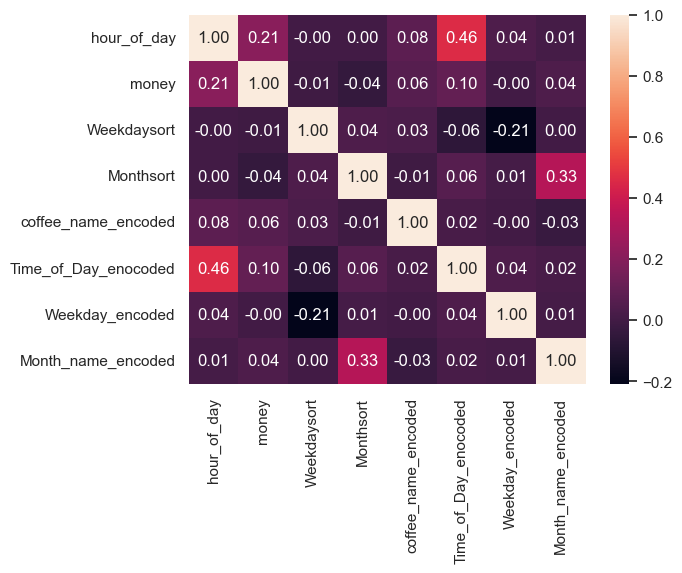

In [ ]:
cl1=['#ff4d01','#ffffff']

sns.set_theme(style='white',palette=cl1)
sns.heatmap(spearman_corr,annot=True,fmt='.2f')
plt.savefig('p1.png',dpi=1000)
plt.show()

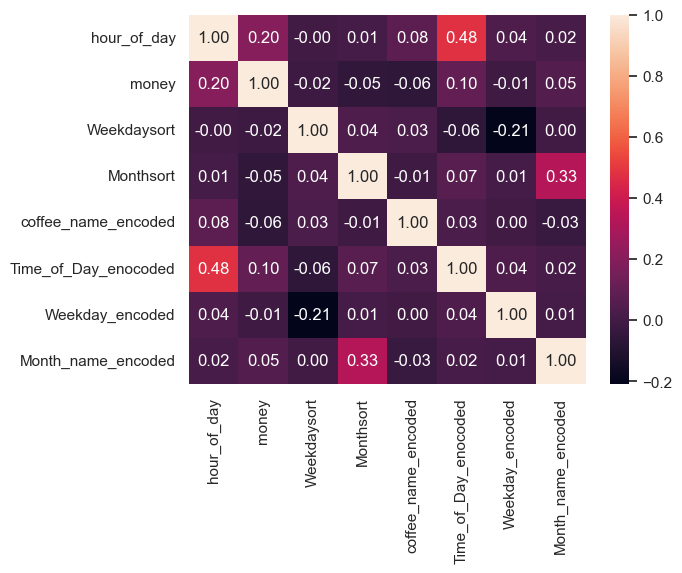

In [ ]:
cl1=['#ff4d01','#ffffff']

sns.set_theme(style='white',palette=cl1)
sns.heatmap(pearson_corr,annot=True,fmt='.2f')
plt.savefig('p2.png',dpi=1000)
plt.show()

In [ ]:
df3.columns

Index(['hour_of_day', 'money', 'Weekdaysort', 'Monthsort',
       'coffee_name_encoded', 'Time_of_Day_enocoded', 'Weekday_encoded',
       'Month_name_encoded'],
      dtype='object')

In [ ]:
cl1=['#ff4d01','#ffffff']

sns.set_theme(style='white',palette=cl1)
sns.kdeplot(df3['coffee_name_encoded'],fill='stack')
plt.savefig('p4.png',dpi=1000)
plt.show()

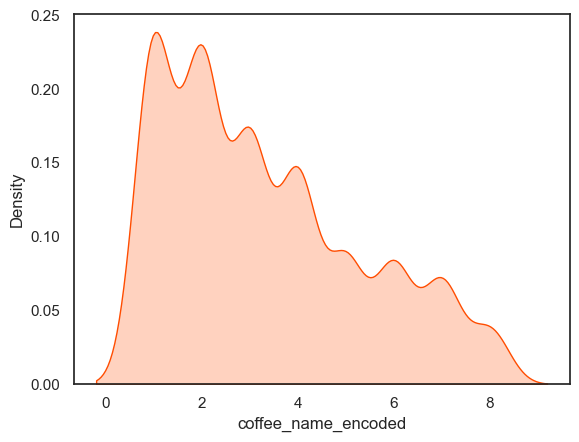

In [ ]:
cl1=['#ff4d01','#ffffff']

sns.set_theme(style='white',palette=cl1)
sns.kdeplot(df3['coffee_name_encoded'],fill='stack')
plt.savefig('p3.png',dpi=1000)
plt.show()

In [217]:
x=df3[['hour_of_day', 'money', 'Weekdaysort', 'Monthsort',
        'Time_of_Day_enocoded', 'Weekday_encoded',
       'Month_name_encoded']]
y=df3['coffee_name_encoded'].squeeze()

In [219]:
most_impact_fetaures=SelectKBest(score_func=f_classif,k=5)
most_impact_fetaures.fit_transform(x,y)

array([[10.  , 38.7 ,  3.  ,  1.  ,  7.  ],
       [12.  , 38.7 ,  3.  ,  0.  ,  7.  ],
       [12.  , 38.7 ,  3.  ,  0.  ,  7.  ],
       ...,
       [14.  , 35.76,  3.  ,  0.  ,  7.  ],
       [15.  , 25.96,  3.  ,  0.  ,  7.  ],
       [18.  , 35.76,  3.  ,  2.  ,  7.  ]], shape=(3547, 5))

In [ ]:
features_names=x.columns[most_impact_fetaures.get_support()]
features_names

Index(['hour_of_day', 'money', 'Monthsort', 'Time_of_Day_enocoded',
       'Month_name_encoded'],
      dtype='object')

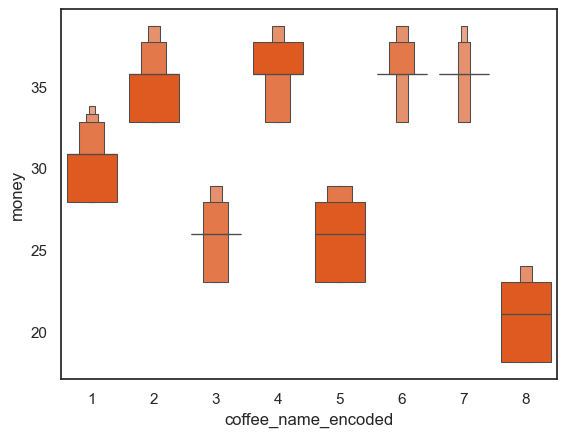

In [ ]:
cl1=['#ff4d01','#ffffff']

sns.set_theme(style='white',palette=cl1)
sns.boxenplot(data=df3,x=df3['coffee_name_encoded'],y=df3['money'])
plt.savefig('p6.png',dpi=1000)
plt.show()

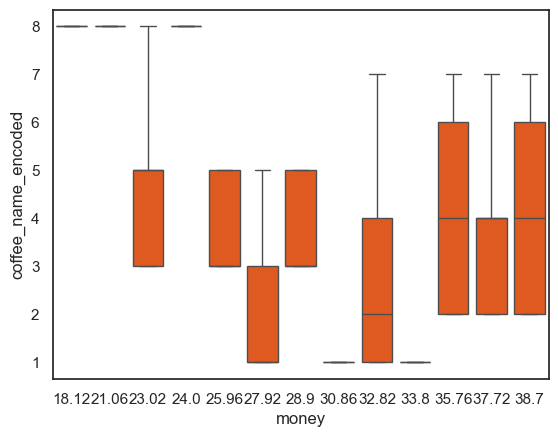

In [ ]:
cl1=['#ff4d01','#ffffff']

sns.set_theme(style='white',palette=cl1)
sns.boxplot(data=df3,x=df3['money'],y=df3['coffee_name_encoded'])
plt.savefig('p7.png',dpi=1000)
plt.show()

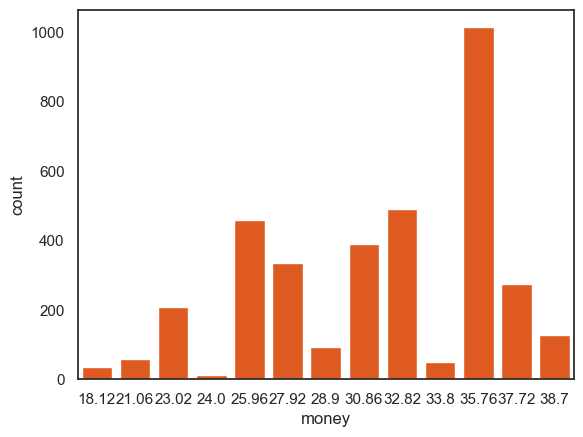

In [ ]:
cl1=['#ff4d01','#ffffff']

sns.set_theme(style='white',palette=cl1)
sns.countplot(data=df3,x=df3['money'])
plt.savefig('p8.png',dpi=1000)
plt.show()

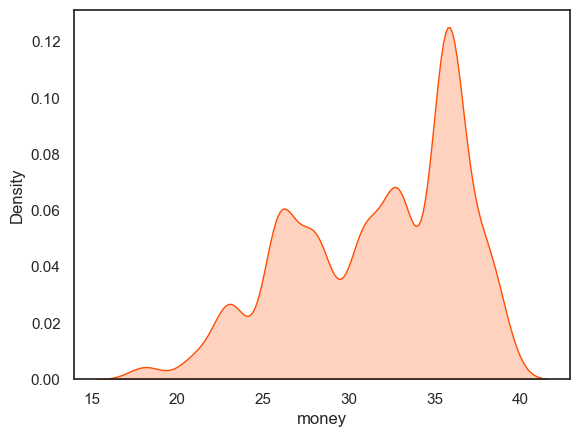

In [ ]:
cl1=['#ff4d01','#ffffff']

sns.set_theme(style='white',palette=cl1)
sns.kdeplot(df3['money'],fill=True)
plt.savefig('p4.png',dpi=1000)
plt.show()

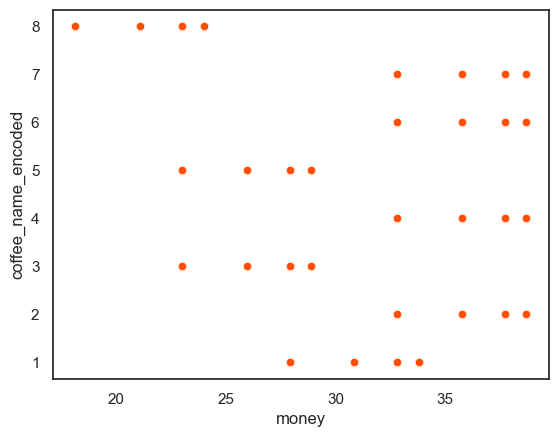

In [ ]:
cl1=['#ff4d01','#ffffff']

sns.set_theme(style='white',palette=cl1)
sns.scatterplot(data=df3,x=df3['money'],y=df3['coffee_name_encoded'])
plt.savefig('p5.png',dpi=1000)
plt.show()

In [ ]:
cl1=['#ff4d01','#ffffff']

sns.set_theme(style='white',palette=cl1)
sns.scatterplot(data=df3,x=df3['money'],y=df3['coffee_name_encoded'])
plt.savefig('p5.png',dpi=1000)
plt.show()

In [ ]:
df3.columns

Index(['hour_of_day', 'money', 'Weekdaysort', 'Monthsort',
       'coffee_name_encoded', 'Time_of_Day_enocoded', 'Weekday_encoded',
       'Month_name_encoded'],
      dtype='object')

In [220]:
skew_data=PowerTransformer(method='yeo-johnson')
df3[['hour_of_day', 'money', 'Weekdaysort', 'Monthsort',
       'coffee_name_encoded', 'Time_of_Day_enocoded', 'Weekday_encoded',
       'Month_name_encoded']]=skew_data.fit_transform(df3[['hour_of_day', 'money', 'Weekdaysort', 'Monthsort',
       'coffee_name_encoded', 'Time_of_Day_enocoded', 'Weekday_encoded',
       'Month_name_encoded']])

In [221]:
df3.sample(10)

,hour_of_day,money,Weekdaysort,Monthsort,Time_of_Day_enocoded,Weekday_encoded,Month_name_encoded,coffee_name_encoded
3011,-0.461386,0.855620,1.071392,-1.323095,-1.255282,-0.406547,-0.839942,0.557494
3314,-1.263282,-1.184713,0.630260,-0.963410,0.115035,-1.588214,0.340992,0.093619
137,0.255689,0.360372,1.071392,-0.963410,-1.255282,-0.406547,0.340992,-1.396246
746,1.517809,1.398102,0.159266,-0.037985,1.185839,0.540091,0.057799,-0.515632
2406,0.255689,0.855620,1.071392,1.465806,-1.255282,-0.406547,-1.162507,-0.515632
1456,0.698284,0.129900,0.159266,0.754018,1.185839,0.540091,1.420959,-0.515632
547,1.117880,1.398102,-0.912962,-0.327356,1.185839,0.968713,0.618210,-0.515632
3469,-1.864154,-1.184713,-0.350343,-0.963410,0.115035,1.376312,0.340992,0.093619
1984,0.255689,0.855620,0.159266,0.998661,-1.255282,0.540091,1.157648,-0.515632
1872,0.698284,-0.297879,-0.350343,0.998661,1.185839,1.376312,1.157648,-1.396246


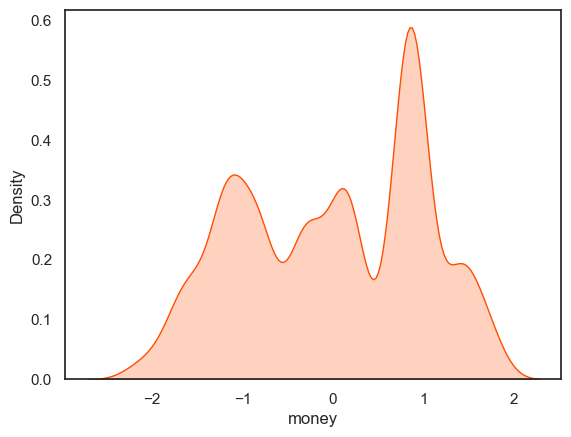

In [223]:
cl1=['#ff4d01','#ffffff']

sns.set_theme(style='white',palette=cl1)
sns.kdeplot(data=df3,x=df3['money'],fill=True)
plt.savefig('p5.png',dpi=1000)
plt.show()

In [ ]:
df3[['hour_of_day', 'money', 'Weekdaysort', 'Monthsort',
       'coffee_name_encoded', 'Time_of_Day_enocoded', 'Weekday_encoded',
       'Month_name_encoded']]=skew_data.inverse_transform(df3[['hour_of_day', 'money', 'Weekdaysort', 'Monthsort',
       'coffee_name_encoded', 'Time_of_Day_enocoded', 'Weekday_encoded',
       'Month_name_encoded']])

In [ ]:
df3.sample(10)

,hour_of_day,money,Weekdaysort,Monthsort,coffee_name_encoded,Time_of_Day_enocoded,Weekday_encoded,Month_name_encoded
914,11.0,32.82,7.0,7.0,4.0,1.0,3.0,5.0
1750,14.0,35.76,2.0,10.0,2.0,0.0,5.0,10.0
3086,20.0,35.76,3.0,2.0,7.0,2.0,6.0,3.0
2088,10.0,35.76,5.0,11.0,2.0,1.0,0.0,9.0
2581,13.0,35.76,1.0,12.0,2.0,0.0,1.0,2.0
1065,11.0,23.02,6.0,8.0,5.0,1.0,2.0,1.0
1162,21.0,27.92,1.0,8.0,1.0,2.0,1.0,1.0
2069,10.0,35.76,3.0,10.0,2.0,1.0,6.0,10.0
3247,12.0,35.76,1.0,3.0,4.0,0.0,1.0,7.0
2593,10.0,30.86,2.0,12.0,1.0,1.0,5.0,2.0


In [ ]:
df3.sample(10)

,hour_of_day,money,Weekdaysort,Monthsort,coffee_name_encoded,Time_of_Day_enocoded,Weekday_encoded,Month_name_encoded
1937,-1.864154,0.855620,-1.555815,0.998661,-0.515632,0.115035,-0.950744,1.157648
3342,0.255689,-0.297879,1.488475,-0.963410,-1.396246,-1.255282,0.084739,0.340992
375,0.480107,-0.860105,0.159266,-0.327356,0.093619,-1.255282,0.540091,0.618210
3220,0.255689,-1.184713,0.630260,-1.323095,0.093619,-1.255282,-1.588214,-0.839942
1375,-1.555703,0.129900,0.630260,0.754018,0.557494,0.115035,-1.588214,1.420959
1327,-1.555703,-0.860105,-1.555815,0.754018,-1.396246,0.115035,-0.950744,1.420959
2994,1.117880,0.855620,0.159266,-1.323095,-0.515632,1.185839,0.540091,-0.839942
2804,1.711231,-1.184713,0.630260,-1.728307,0.093619,1.185839,-1.588214,-0.530960
2256,0.480107,0.855620,1.488475,1.235639,-0.515632,-1.255282,0.084739,0.890227
3057,-0.214310,-0.297879,-0.912962,-1.323095,-1.396246,-1.255282,0.968713,-0.839942


In [ ]:
class Anomolies_detection:
    def __init__(self,data):
        self.data=data
    def main_anomolies_function(self,column):
        Q1=self.data[column].quantile(0.25)
        Q3=self.data[column].quantile(0.75)
        IQR=Q3-Q1
        left_bound=Q1-1.5*IQR 
        right_bound=Q3+1.5*IQR
        mask=(self.data[column]<left_bound) | (self.data[column]>right_bound)
        anomolies_indexes=self.data[column][mask].index.to_list()
        anomolies_data=self.data[column][mask].to_list()
        return anomolies_indexes, list(anomolies_data)
    
numeric_col=df3.select_dtypes(include='number',exclude='object').columns
Anomolies_detection_instance=Anomolies_detection(df3)
store_anomolies=set()
for each_col in numeric_col:
    anomolies_indexes,anomolies_data=Anomolies_detection_instance.main_anomolies_function(each_col)
    counting=len(anomolies_indexes)
    if anomolies_indexes:
        print(f"{each_col} --- > {anomolies_indexes}")
        print(f"{each_col} ---> {anomolies_data}")
        store_anomolies.update(anomolies_indexes)
    else:
        print(f"{each_col} no anomolies data is present")

df4=df3.drop(list(anomolies_indexes),axis=0)
print(f"old dataframe shape is ==>> {df3.shape} and new dataframe shape is ===> {df4.shape}")


hour_of_day no anomolies data is present
money no anomolies data is present
Weekdaysort no anomolies data is present
Monthsort no anomolies data is present
coffee_name_encoded no anomolies data is present
Time_of_Day_enocoded no anomolies data is present
Weekday_encoded no anomolies data is present
Month_name_encoded no anomolies data is present
old dataframe shape is ==>> (3547, 8) and new dataframe shape is ===> (3547, 8)


In [229]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)


In [225]:
x.columns

Index(['hour_of_day', 'money', 'Weekdaysort', 'Monthsort',
       'Time_of_Day_enocoded', 'Weekday_encoded', 'Month_name_encoded'],
      dtype='object')

In [226]:
for each_col in x.columns:
    df3[each_col]=np.log(df3[each_col])

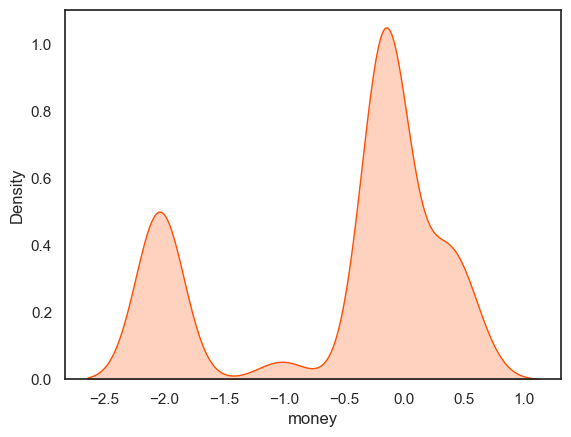

In [230]:
cl1=['#ff4d01','#ffffff']

sns.set_theme(style='white',palette=cl1)
sns.kdeplot(data=df3,x=df3['money'],fill=True)
plt.savefig('p5.png',dpi=1000)
plt.show()

In [231]:
if x.shape[0] == y.shape[0] or x_train.shape[0] == y_train.shape[0]:
    print("shapes are same")
else:
    print("shapes are not same")

shapes are same


In [234]:
class1_logi = LogisticRegression(solver='lbfgs')
class1_logi

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [275]:
cross_score=cross_val_score(class1_logi,x,y,scoring='accuracy',cv=100,n_jobs=-1)
# print(cross_score)
mean_score=np.mean(cross_score)
print(mean_score)

0.3618015873015874


In [236]:
class2_Dece=DecisionTreeClassifier(criterion='entropy',max_depth=10,max_features='sqrt',min_samples_split=30,splitter='best',min_samples_leaf=10)
class2_Dece

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",30
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",'sqrt'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the 

In [273]:
cross_score1=cross_val_score(class2_Dece,x,y,scoring='accuracy',cv=300,n_jobs=-1)
# print(cross_score1)
mean_score1=np.mean(cross_score1)
print(mean_score1)

0.5456060606060606


In [258]:
class3_random=RandomForestClassifier(n_estimators=20,n_jobs=-1,max_depth=10,min_samples_split=100,max_features=1000,min_samples_leaf=100,criterion='entropy')
class3_random

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",20
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",100
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",100
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1000
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metr

In [271]:
cross_score2=cross_val_score(class3_random,x,y,scoring='accuracy',cv=400,n_jobs=-1)
# print(cross_score2)
mean_score2=np.mean(cross_score2)
print(mean_score2)

0.6043055555555555


In [311]:
x.describe()

,hour_of_day,money,Weekdaysort,Monthsort,Time_of_Day_enocoded,Weekday_encoded,Month_name_encoded
count,3547.000000,3547.000000,3547.000000,3547.000000,3547.000000,3547.000000,3547.000000
mean,14.185791,31.645216,3.845785,6.453905,0.987595,3.000000,5.961940
std,4.234010,4.877754,1.971501,3.500754,0.816748,2.038269,3.401994
min,6.000000,18.120000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,10.000000,27.920000,2.000000,3.000000,0.000000,1.000000,3.000000
50%,14.000000,32.820000,4.000000,7.000000,1.000000,3.000000,6.000000
75%,18.000000,35.760000,6.000000,10.000000,2.000000,5.000000,9.000000
max,22.000000,38.700000,7.000000,12.000000,2.000000,6.000000,11.000000


In [316]:
list(df3)

['hour_of_day',
 'money',
 'Weekdaysort',
 'Monthsort',
 'Time_of_Day_enocoded',
 'Weekday_encoded',
 'Month_name_encoded',
 'coffee_name_encoded']

In [317]:
x.columns

Index(['hour_of_day', 'money', 'Weekdaysort', 'Monthsort',
       'Time_of_Day_enocoded', 'Weekday_encoded', 'Month_name_encoded'],
      dtype='object')

In [278]:
class3_random.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",20
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",100
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",100
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1000
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metr

In [280]:
y_pred=class3_random.predict(x_test)
print(y_pred)

[1 2 2 2 8 2 8 2 3 1 8 2 2 2 2 2 3 2 2 8 2 3 2 2 4 1 2 3 2 1 2 1 4 3 2 1 1
 4 2 1 1 2 2 1 4 2 2 3 2 1 1 2 3 2 2 2 1 8 1 1 4 8 2 1 2 2 3 4 1 3 2 1 2 1
 1 2 2 3 2 2 3 1 2 3 2 1 1 1 3 1 2 3 8 3 2 1 3 1 4 3 3 1 1 2 3 2 1 1 2 1 1
 2 1 2 2 8 1 1 4 1 2 3 1 3 2 2 1 3 1 1 3 1 2 2 1 1 1 2 3 2 2 2 2 2 3 1 4 1
 1 1 1 3 2 1 2 1 2 2 3 3 8 1 2 2 1 2 8 3 4 1 2 3 2 1 2 8 3 1 1 2 2 8 1 3 1
 1 1 2 2 2 1 2 2 8 2 8 2 2 2 3 2 2 2 8 1 2 2 1 2 2 2 1 1 1 2 1 1 2 1 1 1 2
 2 1 1 2 2 1 2 2 3 2 1 2 8 1 1 1 1 2 2 1 2 8 8 1 2 1 2 1 2 8 8 2 1 3 1 2 2
 4 3 2 3 1 3 8 3 2 2 2 2 1 3 1 1 1 2 2 8 2 1 1 1 3 2 8 3 3 1 1 2 3 1 1 1 2
 3 1 2 3 1 1 3 3 2 2 1 8 2 1 2 2 2 3 3 2 3 2 3 2 2 2 2 2 3 2 3 2 2 2 1 2 2
 2 2 2 2 2 3 1 8 3 2 1 2 1 2 2 1 2 2 2 2 2 2 3 1 1 3 1 2 1 2 3 3 1 3 3 2 8
 1 1 2 1 2 3 1 1 1 1 1 2 2 3 1 3 2 2 2 8 2 2 3 2 2 2 3 2 1 3 1 2 3 1 2 2 8
 1 2 2 2 3 2 2 1 1 3 2 2 2 3 3 1 2 1 1 1 4 1 3 3 1 1 3 2 2 1 1 2 2 2 4 2 1
 2 1 8 2 3 1 2 1 2 1 1 2 3 4 3 3 2 1 2 8 8 2 2 2 3 1 8 1 2 1 2 8 2 2 3 1 8
 3 1 1 3 2 2 2 1 2 3 2 2 

In [281]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           1       0.76      1.00      0.86       163
           2       0.43      0.83      0.57       156
           3       0.76      0.71      0.74       128
           4       0.27      0.07      0.11        90
           5       0.00      0.00      0.00        48
           6       0.00      0.00      0.00        60
           7       0.00      0.00      0.00        45
           8       0.39      1.00      0.56        20

    accuracy                           0.58       710
   macro avg       0.33      0.45      0.35       710
weighted avg       0.45      0.58      0.48       710



In [283]:
print(confusion_matrix(y_test,y_pred))

[[163   0   0   0   0   0   0   0]
 [ 16 130   0  10   0   0   0   0]
 [ 17   0  91   0   0   0   0  20]
 [  7  77   0   6   0   0   0   0]
 [  9   0  28   0   0   0   0  11]
 [  3  53   0   4   0   0   0   0]
 [  0  43   0   2   0   0   0   0]
 [  0   0   0   0   0   0   0  20]]


In [288]:
print(class3_random.score(x_test,y_pred))

1.0


In [240]:
param_grid={
    'criterion':['gini','entropy'],
    'max_depth':[2,4,6,8,10,12,14,16,18],
    'min_samples_split':[5,10,15,20,25,50,100]
}


grid_searchcv=GridSearchCV(estimator=class3_random,param_grid=param_grid,n_jobs=-1)
grid_searchcv

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","RandomForestC...20, n_jobs=-1)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [2, 4, ...], 'min_samples_split': [5, 10, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed

In [277]:
grid_searchcv.fit(x_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","RandomForestC...20, n_jobs=-1)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [2, 4, ...], 'min_samples_split': [5, 10, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed

In [289]:
joblib.dump(class3_random,"class3_random.joblib")

['class3_random.joblib']

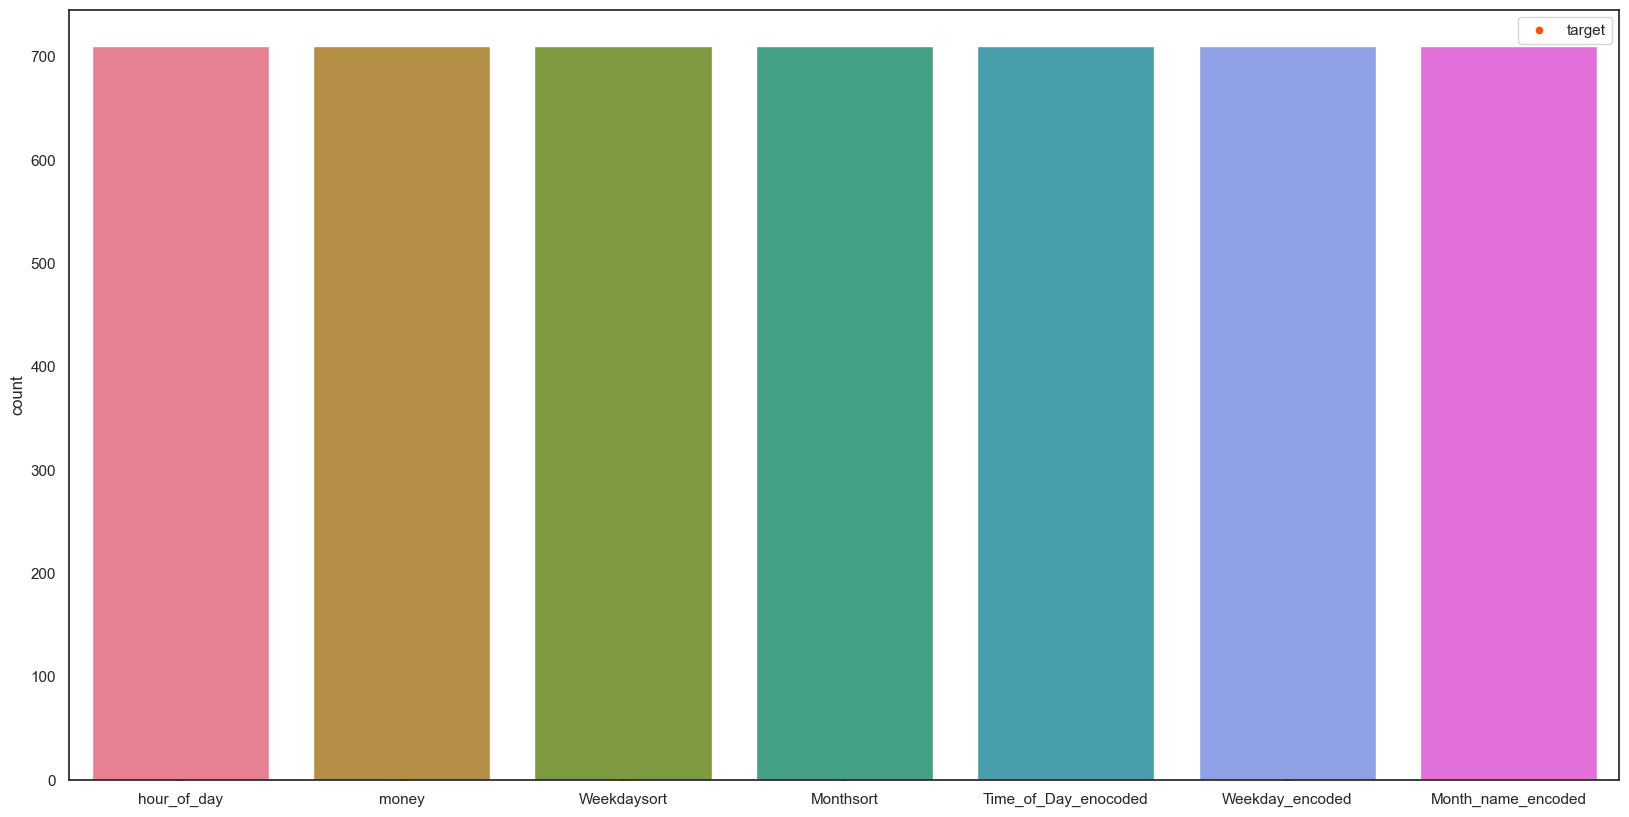

In [ ]:

plt.figure(figsize=(20,10))
sns.scatterplot(y_pred,label="target")
sns.countplot(x_test)
plt.show()